In [11]:
%load_ext autoreload
%autoreload 2
from viewer import view_image
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


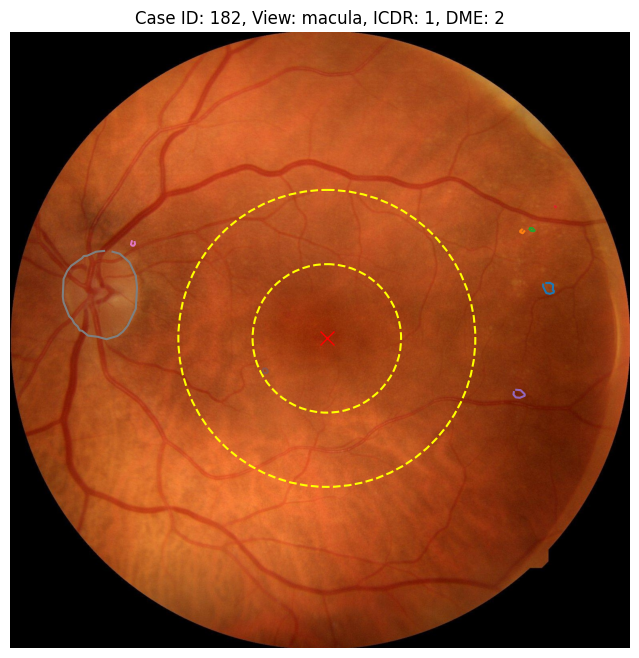

In [101]:
# img_53 = view_image("../HMR.sqlite", 53, "macula")
img = view_image(
    "../HMR.sqlite",
    182,
    "macula",
    show_contours=True,
    draw_etdrs_circle=True,
)
# imgs = [img_53, img_188]

In [109]:
from hmr.predictions import predict_DME, predict_lesions, predict_od_mac, predict_DR
import numpy as np

lesions = predict_lesions(np.asarray(img), 1536)
od_mac = predict_od_mac(np.asarray(img))
dme = predict_DME(lesions, od_mac)
dr = predict_DR(np.asarray(img))
dme, dr


('M2', 0.5572484731674194)

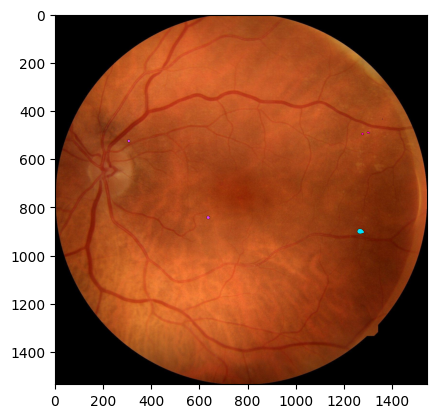

In [110]:
import matplotlib.pyplot as plt
from consts import CMAP

masks = np.asarray(list(lesions.values())).argmax(0)

plt.imshow(img)
plt.imshow(masks, cmap=CMAP)
plt.show()


In [29]:
from pynotate.project import LabelMedProject, ProjectConfig, Label

config = ProjectConfig(
    name="Papilla correction", images_embedded=True, segmentation_enabled=True
)
papilla_label = Label(
    name="Papilla",
    color="#0004FF",
)
project = LabelMedProject.create(
    "papilla_correction", name="Papilla correction", config=config, overwrite=True
)
project.add_label(papilla_label)
for i, img in enumerate(imgs):
    seq_id = project.add_sequence(f"seq_{i + 1:02d}")
    project.add_frame(seq_id, img)